# Exercise Sheet 2 — Dependence & Bivariate data exploration
**Course:** Big Data Science in Finance (WI3436TU)
**Assets:** SPY (S&P 500 ETF), BAC (Bank of America Corporation)
**Sample window:** 2000-01-01 to 2025-12-31

This notebook works through Problems 1-5 of Exercise Sheet 2 using monthly log-returns
of SPY and BAC. Code cells compute the required quantities and produce the plots;
markdown cells contain the written discussion and proofs.

## Setup

In [ ]:
# pip install pyvinecopulib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 39.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.9 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
import yfinance as yf
import pyvinecopulib as pv

pd.set_option("display.float_format", lambda x: f"{x:0.6f}")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

TICKERS = ["SPY", "BAC"]
START_DATE = "2000-01-01"
END_DATE = "2025-12-31"

SEED = 42
rng = np.random.default_rng(SEED)

In [4]:
def download_prices(ticker, start_date, end_date):
    """Download raw OHLC(V) + Adj Close data for a single ticker.

    yfinance treats `end` as exclusive, so we push it one day forward to make
    end_date inclusive. If end_date itself is not a trading day, the download
    naturally stops at the closest previous trading day.
    """
    end_inclusive = (pd.Timestamp(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    df = yf.download(
        ticker,
        start=start_date,
        end=end_inclusive,
        auto_adjust=False,   # keep Close and Adj Close as separate columns
        progress=False,
    )
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index = pd.to_datetime(df.index)
    return df.sort_index()


def choose_price_series(df):
    """P_d := Adj Close if available, otherwise Close (never mixed within an asset)."""
    if "Adj Close" in df.columns and df["Adj Close"].notna().any():
        col = "Adj Close"
    else:
        col = "Close"
    return df[col].rename("Price"), col

### Notation

For asset $j \in \{1, 2\}$, let $P^{(j)}_d$ denote the chosen daily price on trading day $d$:
$$P^{(j)}_d := \begin{cases} \texttt{Adj Close} \text{ for asset } j \text{ on day } d, & \text{if available,}\\ \texttt{Close} \text{ for asset } j \text{ on day } d, & \text{otherwise.}\end{cases}$$

Do not mix `Close` and `Adj Close` within an asset. Use trading days only; do not fill
non-trading days; drop missing prices before computing returns. For this exercise, convert the
daily price series into a monthly price series by taking the last available trading day in each
calendar month. Let $S^{(j)}_m$ denote the monthly price for month $m$ and asset $j$. Define the
one period monthly log-return by
$$r^{(j)}_m := \log S^{(j)}_m - \log S^{(j)}_{m^-},$$
where $m^-$ denotes the previous month in the monthly series for asset $j$.

Let $\mathcal T_j$ denote the set of months on which $r^{(j)}_m$ is available, and let
$\mathcal T := \mathcal T_1 \cap \mathcal T_2 = \{m_1, \dots, m_n\}$ be the common set of return
months, listed in increasing order. Define the bivariate sample by
$$\mathbf R_t := \begin{pmatrix} X_t \\ Y_t \end{pmatrix} := \begin{pmatrix} r^{(1)}_{m_t} \\ r^{(2)}_{m_t} \end{pmatrix}, \qquad t = 1, \dots, n.$$
The associated data matrix is
$$\mathbf R := \begin{pmatrix} X_1 & Y_1 \\ \vdots & \vdots \\ X_n & Y_n \end{pmatrix} \in \mathbb R^{n \times 2}.$$

## Problem 1

Download price data for SPY and BAC over the given time window:

### a)

State the chosen price column for each asset, construct the bivariate return sample
$\{\mathbf R_t\}_{t=1}^n$, and report $n$ together with the first and last months.

In [9]:
monthly_returns = {}

for ticker in TICKERS:
    raw = download_prices(ticker, START_DATE, END_DATE) # gets the daily data
    price, col = choose_price_series(raw) # chooses the price series to use (Adj Close if available, otherwise Close)
    price = price.dropna() # removes missing prices before any returns are calculated

    # monthly price = last available trading day of each calendar month
    monthly_price = price.groupby(price.index.to_period("M")).last()
    monthly_returns[ticker] = np.log(monthly_price).diff().dropna() # compute log returns
    # diff() : uses previous row to compute the difference, so the first row is NaN and is dropped by dropna()
    # -> first return is February 2000, last return is December 2025

    print(f"{ticker}: price column = {col}")

# common months T = T1 ∩ T2 (inner join), X = SPY, Y = BAC
R = pd.concat(monthly_returns, axis=1, join="inner").sort_index() 
# pd.concat() : each ticker becomes a column named after its key in the dictionary
# join="inner" : only keep rows (months) that are present in all columns (tickers)
X = R["SPY"] 
Y = R["BAC"]
n = len(R)

print(f"n = {n} monthly returns, first month = {R.index[0]}, last month = {R.index[-1]}")
R.head()

SPY: price column = Adj Close
BAC: price column = Adj Close
n = 311 monthly returns, first month = 2000-02, last month = 2025-12


,SPY,BAC
Date,,
2000-02,-0.015344,-0.051633
2000-03,0.092501,0.141910
2000-04,-0.035752,-0.067802
2000-05,-0.015848,0.132578
2000-06,0.019490,-0.254056


### b)

Generate a scatterplot of the sample $\{(X_t, Y_t) : t = 1, \dots, n\}$,

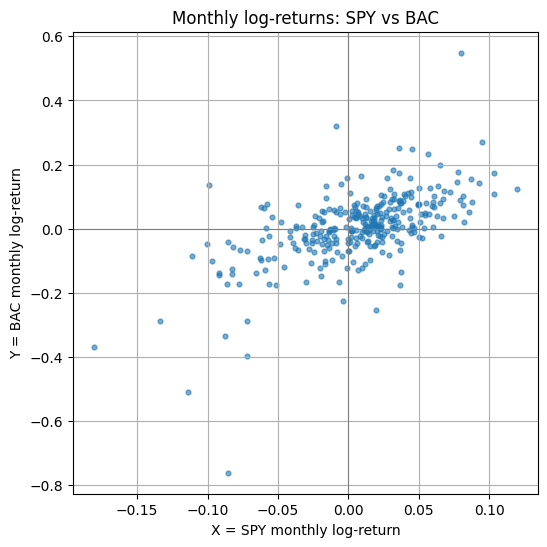

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X, Y, s=12, alpha=0.6)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("X = SPY monthly log-return")
ax.set_ylabel("Y = BAC monthly log-return")
ax.set_title("Monthly log-returns: SPY vs BAC")
plt.show()

### c)

Explain what the scatterplot and tells you that two separate univariate plots of
$\{X_t\}_{t=1}^n$ and $\{Y_t\}_{t=1}^n$ cannot tell you.

**Discussion.**

Two separate univariate plots (histograms, boxplots or time series) of $\{X_t\}$ and $\{Y_t\}$ only show the **marginal distributions**: the location, spread, skewness and tails of each asset on its own. For example, they show that BAC is much more volatile than SPY (BAC returns range from about $-0.76$ to $+0.55$, SPY from about $-0.18$ to $+0.12$) and that both have a few large negative months. They contain **no information about how the two series move together**. Randomly shuffling the $Y_t$ over time would leave its univariate plot unchanged but completely destroy its relationship with $X_t$. The same two marginals are compatible with independence, perfect positive dependence, perfect negative dependence, or anything in between.

The scatterplot shows the **joint distribution** of $(X_t, Y_t)$, i.e. the dependence structure:

- **Direction and strength of dependence.** The cloud slopes clearly upward and most points lie in the first and third quadrants: in months where SPY goes up, BAC tends to go up too, and vice versa. BAC is a large bank inside the S&P 500, so both are driven by the same market factor. The dependence is positive but far from perfect: the cloud is wide, and there are months where the two move in opposite directions (e.g. SPY $\approx -0.10$ with BAC $\approx +0.14$).
- **Joint extremes (tail dependence).** The most extreme observations lie in the **lower-left quadrant**: SPY losses of 8–18% coincide with BAC losses of 30–76% in the same month (mainly the 2008–2009 financial crisis). The univariate plots show that each asset has extreme negative months, but only the scatterplot shows that these crashes happen **at the same time**. This is what matters for portfolio risk and diversification.
- **Asymmetry.** The lower-left tail is much longer and more populated than the upper-right tail. Apart from a single large rebound month (SPY $\approx +0.08$, BAC $\approx +0.55$), joint gains are moderate. Joint crashes are therefore more extreme than joint rallies, i.e. the dependence is stronger in bad times. A single correlation number, or a symmetric (elliptical) model such as the bivariate Gaussian, cannot capture this.
- **Shape of the relationship.** The centre of the cloud is fairly compact and roughly linear, but the vertical spread grows strongly for large negative $X$. A small drop in the market can come with a very large drop in BAC (e.g. SPY $\approx -0.085$, BAC $\approx -0.76$). So the relationship is not "linear plus constant noise".

In short, the univariate plots describe each asset's risk in isolation, whereas the scatterplot shows how the risks **combine**: the sign and strength of the co-movement, its non-linear and asymmetric shape, and especially that large losses occur together. This is exactly the information needed to assess diversification and portfolio risk (Problems 1d and 4e).

### d)

Compute the empirical joint lower tail event frequency
$\frac{1}{n}\sum_{t=1}^n \mathbf 1\{X_t \le q^X_{0.05},\ Y_t \le q^Y_{0.05}\}$, where $q^X_{0.05}$
and $q^Y_{0.05}$ are the empirical 5% quantiles of the samples $\{X_t\}_{t=1}^n$ and
$\{Y_t\}_{t=1}^n$, respectively. Compare this value with $0.05^2 = 0.0025$, the value one would
expect under independence of the two lower tail events.

In [12]:
q_X = X.quantile(0.05)
q_Y = Y.quantile(0.05)

both_in_lower_tail = (X <= q_X) & (Y <= q_Y)
joint_freq = both_in_lower_tail.mean()

print(f"q_X(0.05) = {q_X:.4f},  q_Y(0.05) = {q_Y:.4f}")
print(f"number of months with both in the lower tail = {both_in_lower_tail.sum()}")
print(f"empirical joint lower tail frequency = {joint_freq:.4f}")
print(f"value under independence 0.05^2     = {0.05**2:.4f}")
print(f"ratio                                = {joint_freq / 0.05**2:.2f}")

q_X(0.05) = -0.0798,  q_Y(0.05) = -0.1572
number of months with both in the lower tail = 6
empirical joint lower tail frequency = 0.0193
value under independence 0.05^2     = 0.0025
ratio                                = 7.72


**Discussion.**

## Problem 2

For the sample $\{\mathbf R_t\}_{t=1}^n$:

### a)

Compute the sample Pearson correlation and the sample Kendall's $\tau$ of
$\{(X_t, Y_t) : t = 1, \dots, n\}$ and interpret the estimated dependence strength among the
assets.

In [ ]:
pearson = st.pearsonr(X, Y).statistic
kendall = st.kendalltau(X, Y).statistic

print(f"Pearson correlation = {pearson:.4f}")
print(f"Kendall's tau       = {kendall:.4f}")

**Discussion.**

### b)

Apply the strictly increasing transformation $g(x) = \operatorname{sign}(x)\log(1 + 250|x|)$.
Compare the two dependence measures for the original sample $\{(X_t, Y_t)\}_{t=1}^n$ and the
transformed sample $\{(g(X_t), g(Y_t))\}_{t=1}^n$.

In [ ]:
def g(x):
    return np.sign(x) * np.log(1 + 250 * np.abs(x))

gX, gY = g(X), g(Y)

comparison = pd.DataFrame(
    {
        "Pearson": [st.pearsonr(X, Y).statistic, st.pearsonr(gX, gY).statistic],
        "Kendall tau": [st.kendalltau(X, Y).statistic, st.kendalltau(gX, gY).statistic],
    },
    index=["original (X, Y)", "transformed (g(X), g(Y))"],
)
comparison

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(X, Y, s=12, alpha=0.6)
axes[0].set_title("original sample")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[1].scatter(gX, gY, s=12, alpha=0.6, color="tab:orange")
axes[1].set_title("transformed sample")
axes[1].set_xlabel("g(X)")
axes[1].set_ylabel("g(Y)")
fig.tight_layout()
plt.show()

**Discussion.**

## Problem 3

### a)

Fit a bivariate Gaussian model $\mathcal N_2(\hat{\boldsymbol\mu}, \hat{\boldsymbol\Sigma})$ by
maximum likelihood estimation. Estimate the parameters
$$\hat{\boldsymbol\mu} = \begin{pmatrix} \hat\mu_X \\ \hat\mu_Y \end{pmatrix}, \qquad
\hat{\boldsymbol\Sigma}_{\text{MLE}} = \begin{pmatrix} \hat\sigma_X^2 & \hat\rho\,\hat\sigma_X\hat\sigma_Y \\ \hat\rho\,\hat\sigma_X\hat\sigma_Y & \hat\sigma_Y^2 \end{pmatrix}.$$

In [ ]:
# Gaussian MLE: sample mean and covariance with divisor n (ddof=0)
mu_hat = R.mean().to_numpy()
Sigma_hat = R.cov(ddof=0).to_numpy()

sigma_X = np.sqrt(Sigma_hat[0, 0])
sigma_Y = np.sqrt(Sigma_hat[1, 1])
rho_hat = Sigma_hat[0, 1] / (sigma_X * sigma_Y)

print(f"mu_X = {mu_hat[0]:.6f},  mu_Y = {mu_hat[1]:.6f}")
print(f"sigma_X = {sigma_X:.6f},  sigma_Y = {sigma_Y:.6f},  rho = {rho_hat:.4f}")
print("Sigma_MLE =")
print(Sigma_hat)

### b)

Generate an i.i.d. sample $\{\widetilde{\mathbf R}_t\}_{t=1}^n$ of size $n$ from the fitted
bivariate Gaussian model. Compare the empirical sample $\{\mathbf R_t\}_{t=1}^n$ to the simulated
sample $\{\widetilde{\mathbf R}_t\}_{t=1}^n$ on the same scale with a scatter plot.

In [ ]:
R_gauss = rng.multivariate_normal(mu_hat, Sigma_hat, size=n)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
axes[0].scatter(X, Y, s=12, alpha=0.6)
axes[0].set_title("observed sample")
axes[1].scatter(R_gauss[:, 0], R_gauss[:, 1], s=12, alpha=0.6, color="tab:orange")
axes[1].set_title("simulated bivariate Gaussian sample")
for ax in axes:
    ax.set_xlabel("X = SPY")
    ax.set_ylabel("Y = BAC")
fig.tight_layout()
plt.show()

### c)

Analyze/diagnose the Gaussian fit using marginal Q–Q plots for $\{X_t\}_{t=1}^n$ and
$\{Y_t\}_{t=1}^n$ against their fitted Gaussian margins.

In [ ]:
def qq_plot(ax, data, mu, sigma, title):
    """Ordered data (y-axis) against fitted N(mu, sigma^2) quantiles (x-axis)."""
    data_sorted = np.sort(data)
    probs = (np.arange(1, len(data) + 1) - 0.5) / len(data)
    theoretical = st.norm.ppf(probs, loc=mu, scale=sigma)

    ax.scatter(theoretical, data_sorted, s=10)
    ax.plot(theoretical, theoretical, color="red", lw=1, label="45° line")
    ax.set_xlabel("fitted Gaussian quantiles")
    ax.set_ylabel("empirical quantiles")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
qq_plot(axes[0], X, mu_hat[0], sigma_X, "Normal Q-Q plot: X = SPY")
qq_plot(axes[1], Y, mu_hat[1], sigma_Y, "Normal Q-Q plot: Y = BAC")
fig.tight_layout()
plt.show()

### d)

Based on the diagnostics in (b)–(c), argue whether the fitted bivariate Gaussian is adequate.

**Discussion.**

## Problem 4

### a)

Construct pseudo-observations $U_t := \frac{\operatorname{rank}(X_t)}{n+1}$ and
$V_t := \frac{\operatorname{rank}(Y_t)}{n+1}$ on the copula scale (in the unit square). Plot the
sample $\{(U_t, V_t) : t = 1, \dots, n\}$.

In [ ]:
U = X.rank() / (n + 1)
V = Y.rank() / (n + 1)
UV = np.column_stack([U, V])   # n x 2 array, used by pyvinecopulib below

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(U, V, s=12, alpha=0.6)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("U = rank(X) / (n+1)")
ax.set_ylabel("V = rank(Y) / (n+1)")
ax.set_title("Pseudo-observations on the copula scale")
plt.show()

### b)

Explain what is lost and what is retained when $\{\mathbf R_t\}_{t=1}^n$ is replaced by
$\{(U_t, V_t)\}_{t=1}^n$.

**Discussion.**

### c)

Using `pyvinecopulib` library, fit

i) a Gaussian copula,

ii) a $t$-copula,

iii) a Gumbel copula, allowing its rotations,

iv) an independence copula.

Estimate the parameters and analyze the corresponding maximized pseudo log-likelihood and BIC.
For the Gumbel family, also report the selected rotation in $\{0^\circ, 90^\circ, 180^\circ, 270^\circ\}$.
Select the family–rotation combination with the smallest BIC.

In [ ]:
families = {
    "Gaussian": pv.BicopFamily.gaussian,
    "t": pv.BicopFamily.student,
    "Gumbel": pv.BicopFamily.gumbel,
    "independence": pv.BicopFamily.indep,
}

fitted_copulas = {}
rows = []

for name, family in families.items():
    # restricting the family set to one family fits that family;
    # for Gumbel, the best rotation (0, 90, 180, 270) is selected automatically
    controls = pv.FitControlsBicop(family_set=[family])
    cop = pv.Bicop.from_data(UV, controls=controls)
    fitted_copulas[name] = cop

    rows.append({
        "family": name,
        "rotation": cop.rotation,
        "parameters": np.round(cop.parameters.flatten(), 4),
        "pseudo log-lik": cop.loglik(UV),
        "BIC": cop.bic(UV),
    })

copula_table = pd.DataFrame(rows).set_index("family")
copula_table

In [ ]:
best_name = copula_table["BIC"].idxmin()
best_copula = fitted_copulas[best_name]

print(f"Smallest BIC: {best_name} copula, rotation = {best_copula.rotation} degrees")
print(best_copula)

**Discussion.**

### d)

Use empirical marginal quantile functions to transform a sample to the return scale (using the
copula fitted in c) with the best BIC value). Generate a scatterplot of

i) the observed sample $\{\mathbf R_t\}_{t=1}^n$,

ii) the fitted bivariate Gaussian sample from Problem 3,

iii) the selected copula sample on the return scale.

Discuss your findings.

In [ ]:
# simulate n points (U, V) from the selected copula
UV_sim = best_copula.simulate(n, seeds=[SEED])

# back to the return scale with the empirical quantile functions of X and Y
X_cop = np.quantile(X, UV_sim[:, 0], method="inverted_cdf")
Y_cop = np.quantile(Y, UV_sim[:, 1], method="inverted_cdf")
R_copula = np.column_stack([X_cop, Y_cop])

samples = {
    "observed sample": R.to_numpy(),
    "bivariate Gaussian (Problem 3)": R_gauss,
    f"{best_name} copula + empirical margins": R_copula,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, (title, sample) in zip(axes, samples.items()):
    ax.scatter(sample[:, 0], sample[:, 1], s=12, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("X = SPY")
    ax.set_ylabel("Y = BAC")
fig.tight_layout()
plt.show()

**Discussion.**

### e)

For each of the three samples in (d), construct the equally weighted portfolio loss
$$L_t = -\frac{X_t + Y_t}{2}.$$
Compute its empirical 95% VaR and ES. Which fitted model gives values closest to those obtained
from the observed sample? Briefly explain why.

In [ ]:
alpha = 0.95
risk_rows = []

for title, sample in samples.items():
    L = -(sample[:, 0] + sample[:, 1]) / 2
    VaR = np.quantile(L, alpha)
    ES = L[L >= VaR].mean()   # average loss beyond the VaR
    risk_rows.append({"sample": title, "VaR 95%": VaR, "ES 95%": ES})

risk_table = pd.DataFrame(risk_rows).set_index("sample")
risk_table

**Discussion.**

## Problem 5

Let $U$ and $V$ be random variables with $\mathrm{Unif}(0, 1)$ marginal distributions and let
$C(u, v) := \mathbb P(U \le u, V \le v)$ denote their copula.

### a)

Prove that, for every $u, v \in [0, 1]$, $\max\{u + v - 1, 0\} \le C(u, v) \le \min\{u, v\}$.

**Proof.**

### b)

Show that both bounds are attainable by considering separately $V = U$ and $V = 1 - U$. Derive
the copula in each case.

**Solution.**